# __Modélisation d'un système proie-prédateur__
LICHTFELD Ben

ROBIN Victor

## __Introduction__

Face à la complexité inhérente aux systèmes dynamique, la modélisation mathématique s'est imposée comme un outil indispensable. Elle offre un cadre formel pour explorer les hypothèses, tester les mécanismes et, in fine, tenter de reproduire et de comprendre les dynamiques qui gouvernent les interactions par exemple entre les populations de proies et de prédateurs.

On peut alors se demander : __Comment peut-on modéliser fidélement les dynamiques réelles des populations proies-prédateurs observées dans la nature ?__

Nous allons dans un premier temps nous intéresser aux équations simples de Lotka-Volterra et les résoudre. Nous observerons comment les populations de proies et de prédateurs évoluent en fonction du temps, et nous observerons les cycles de population qui en résultent. Ensuite, nous allons ajouter une croissance logistique des proies pour rendre le modèle plus réaliste. 

Dans un second temps, nous allons simuler le comportement individuel des proies et des prédateurs en utilisant des automates cellulaires. Nous allons observer comment les proies et les prédateurs se déplacent et interagissent les uns avec les autres au cours du temps et éventuellement voir si le modèle de Lotka-Volterra en émerge.

Enfin, nous allons comparer les résultats des deux modèles à l'aide de données réelles sur une population spécifique de proies et de prédateurs (lynx du Canada et lièvre d'Amérique). Nous allons voir quel modèle est le plus compatible avec les données et quelles conclusions nous pouvons en tirer sur les interactions entre les espèces dans la nature.


## __Partie 1 : Résolution numérique des équations de Lotka-Volterra__

Les équations de Lotka-Volterra, également connues sous le nom de "modèle proie-prédateur", sont un ensemble de deux équations différentielles non linéaires du premier ordre. Elles ont été indépendamment proposées par Alfred J. Lotka en 1925, dans un contexte de modélisation de la dynamique des populations en chimie et en biologie, et par Vito Volterra en 1926, à partir d’une observation écologique.

Elles s'écrivent sous la forme suivante :
$$
\begin{cases}
\frac{dx}{dt} &= \alpha x - \beta xy \\
\frac{dy}{dt} &= \mu xy - \gamma y
\end{cases}
$$
où :
- $x$ est la population de proies
- $y$ est la population de prédateurs
- $\alpha$ est le taux de croissance des proies (constant, indépendant du nombre de prédateurs)
- $\beta$ est le taux de prédation des proies dû aux prédateurs rencontrés
- $\mu$ est le taux de reproduction des prédateurs en fonction des proies rencontrées et mangées
- $\gamma$ est le taux de mortalité des prédateurs (constant, indépendant du nombre de proies)

Ce modèle décrit les interactions entre deux espèces, une proie et un prédateur, il s'attache au domaine de la dynamique des populations. Volterra s'est d'abord demandé pourquoi les populations de poissons prédateurs et de poissons proies dans la mer Adriatique variaient de manière cyclique. Il a alors proposé un modèle mathématique pour expliquer ces variations, qui fera partie de notre étude.

### __1.1. Hypothèses__
Avant de commencer, nous allons faire quelques hypothèses sur les paramètres du modèle. Remarquons que cela peut s'appliquer à n'importe quel type de proie et de prédateur, mais que les valeurs des paramètres peuvent varier d'un écosystème à l'autre.

Nous faisons l'hypothèse que tous les paramètres considérés sont constants et ne varient pas au cours du temps afin de simplifier le modèle.  
Nous allons estimer ces paramètres.  
On postule que la constante $\alpha$ est égale à $\frac{4}{5}$.  Cette valeur est inférieure à 1 afin de traduire une croissance modérée de la population de proies.  
On suppose que l'hypothèse que la constante $\beta$ est égale à $\frac{4}{3}$. Une valeur supérieure à 1 traduit une forte prédation des proies par les prédateurs.  
Nous considérons que la constante $\mu$ est égale à $\frac{5}{6}$ qui est proche mais inférieure à 1 car les prédateurs ne se reproduisent pas à chaque rencontre avec une proie.  
On adopte l'hypothèse selon laquelle la constante $\gamma$ est égale à $\frac{2}{3}$ qui est inférieure à 1 pour traduire une mortalité modérée des prédateurs.

On suppose qu’il n’y a ni immigration ni émigration des populations : les proies et les prédateurs évoluent dans un système fermé, sans échange avec l’extérieur.

On suppose que les effets des interactions (comme la prédation ou la reproduction) sont instantanés. Il n’y a pas de délai entre, par exemple, la capture d’une proie et la reproduction d’un prédateur.

On suppose que les populations sont homogènes et uniformément réparties dans l’espace, ce qui implique que les rencontres entre individus sont aléatoires et proportionnelles à la taille des populations.

On suppose que tous les individus sont identiques au sein de chaque espèce : il n’y a pas de distinction liée à l’âge, au sexe ou à l’état de santé.

### __1.2. Résolution de l'équation__

Pour résoudre les équations de Lotka-Volterra, nous allons utiliser la méthode de Runge-Kutta d'ordre 4. Nous allons définir une fonction qui prend en entrée les paramètres du modèle, les conditions initiales et le temps d'intégration, et qui renvoie les populations prédites au cours du temps.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable

In [11]:
def rk4(func: Callable, t_i: float, v_i: float, step: float):
    """
        Méthode de Runge-Kutta d'ordre 4 pour une étape de temps donnée.
        :param func: Fonction à dériver
        :param t_i: Temps à l'instant i
        :param v_i: Valeur de la fonction à l'instant i
        :param step: Pas de temps
        :return: Nouvelle valeur après application de la méthode RK4
    """
    k1 = func(t_i, v_i)
    k2 = func(t_i + step / 2, v_i + step / 2 * k1)
    k3 = func(t_i + step / 2, v_i + step / 2 * k2)
    k4 = func(t_i + step, v_i + step * k3)
    return v_i + (step / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

def integrate(start, end, step, v_ini: tuple, system: Callable):
    '''
        Fonction qui résout un système d'équations différentielles
        start : float : Temps de début
        end : float : Temps de fin
        step : float : Pas de temps
        v_ini : tuple : Conditions initiales
        system : function : Système d'équations différentielles
        return : tuple : (t, v) : tableau temps et tableau de solution
    '''
    interval = end - start
    num_points = int(interval / step) + 1
    t = np.linspace(start, end, num_points)

    solutions = np.empty((len(v_ini), num_points))

    # Condition initiale
    solutions[:, 0] = v_ini 

    for i in range(num_points - 1):
        # Calcul de la valeur suivante
        solutions[:, i + 1] = rk4(system, t[i], solutions[:, i], step)

    return t, solutions


Maintenant que nous avons défini la fonction de Runge-Kutta, nous allons l'utiliser pour résoudre les équations de Lotka-Volterra.

In [12]:
# choix des paramètres
alpha = 4/5
beta = 4/3
gamma = 2/3
mu = 5/6

def lotka_volterra(t_i: float, v_i: float):
    """
        Système d'équations différentielles de Lotka-Volterra
        :param t_i: Temps à l'instant i
        :param v_i: Valeur de la fonction à l'instant i
        :return: Dérivée du système
    """
    x, y = v_i
    dx_dt = x * (alpha - beta * y)
    dy_dt = y * (- gamma + mu * x)
    return np.array([dx_dt, dy_dt])

Résolvons les équations de Lotka-Volterra avec plusieurs conditions initiales différentes.

In [13]:
v_ini_list = [(1, 3),(0.8, 1.2), (1.2, 0.5), (2, 2), (1, 1)]
step = 0.01
t_i = 0
t_f = 80
t_list, v_list = [], []
for v_ini in v_ini_list:
    t, solutions = integrate(t_i, t_f, step, v_ini, lotka_volterra)
    t_list.append(t)
    v_list.append(solutions)

### __1.3. Diagramme de phase__

Une fois les équations de Lotka-Volterra résolues, on peut tracer le diagramme de phase. Ce diagramme permet de visualiser l'évolution de la population des prédateurs en fonction de celle des proies. On peut ainsi observer les cycles de croissance et de décroissance des deux populations.

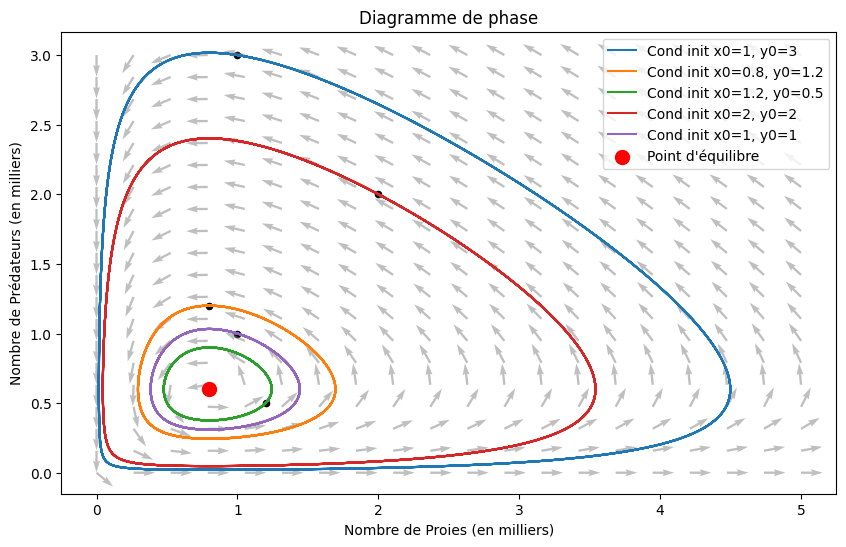

In [14]:
plt.figure(figsize=(10, 6))
for t, solutions, v_i in zip(t_list, v_list, v_ini_list):
    plt.plot(solutions[0], solutions[1], label=f'Cond init x0={v_i[0]}, y0={v_i[1]}')
    plt.scatter(v_i[0], v_i[1], c='black', s=20)

# Tracer les champs de vecteurs
x = np.linspace(1e-6, 5, 20)
y = np.linspace(1e-6, 3, 20)
X, Y = np.meshgrid(x, y)
U = X * (alpha - beta * Y)
V = Y * (-gamma + mu * X)
# Normalisation des vecteurs
norm = np.sqrt(U**2 + V**2)
U /= norm
V /= norm
plt.quiver(X, Y, U, V, color='gray', alpha=0.5)

# Point d'équilibre
plt.scatter(gamma / mu, alpha / beta, c='red', s=100, label='Point d\'équilibre')
plt.xlabel('Nombre de Proies (en milliers)')
plt.ylabel('Nombre de Prédateurs (en milliers)')
plt.title('Diagramme de phase')
plt.legend()
plt.show()

On remarque que les populations de proies et de prédateurs oscillent autour d'un point d'équilibre.
Cette position d'équilibre est donnée pour $x'=0$ et $y'=0$, c'est-à-dire lorsque les deux populations n'évoluent plus.

Analytiquement, on a:

$$
\begin{cases}
x' = x(\alpha - \beta y) = 0 \\
y' = y(\mu x - \gamma) = 0
\end{cases}
$$
On en déduit que les points d'équilibre sont donnés par les équations suivantes:

$$
\begin{cases}
x = 0 \\
y = 0
\end{cases}
\quad \text{ou} \quad
\begin{cases}
\alpha - \beta y = 0 \Rightarrow y = \frac{\alpha}{\beta} \\
\mu x - \gamma = 0 \Rightarrow x = \frac{\gamma}{\mu}
\end{cases}
$$
Le premier point d'équilibre est trivial, il correspond à l'extinction des deux populations. Le second point d'équilibre $\left( \frac{\frac{2}{3}}{\frac{5}{6}}, \frac{\frac{4}{5}}{\frac{4}{3}} \right) = \left( \frac{4}{5}, \frac{3}{5} \right)$

correspond à une coexistence stable des populations de proies et de prédateurs, où le taux de reproduction des proies est équilibré par le taux de prédation, et où le taux de reproduction des prédateurs est équilibré par leur taux de mortalité. Cela représente une situation où les deux populations restent constantes dans le temps.

On remarque également que le point (0,0) est stable s'il y a une variation de la population des prédateurs. En effet, sans proies, les prédateurs ne peuvent pas survivre. On retourne donc à l'état d'équilibre (0,0).
Cependant, si il y a une variation de la population des proies, la population des proies va croître indéfiniment. On ne peut donc pas dire que le point (0,0) est stable. C'est donc un point selle.

On peut également interpréter les courbes de phase.

Quand il y a peu de prédateurs, la population de proies augmente rapidement. On a presque une droite horizontale. Quand la population de proies augmente, la population de prédateurs augmente également. Jusqu'à un certain point, la population de prédateurs augmente plus vite que la population de proies. Enfin quand il y a presque plus de proies, la population de prédateurs diminue rapidement. Il y a presque une droite verticale. 

En traçant le champ de vecteur correspondant à la direction d'évolution des populations, on peut observer que toutes les courbes de phase tournent autour du point d'équilibre stable étudié précédemment, et que pour toutes les conditions initiales, les courbes de phase ont la même forme. 

### __1.4. Evolution temporelle des populations__
Représentons à présent l'évolution temporelle des populations de proies et de prédateurs.

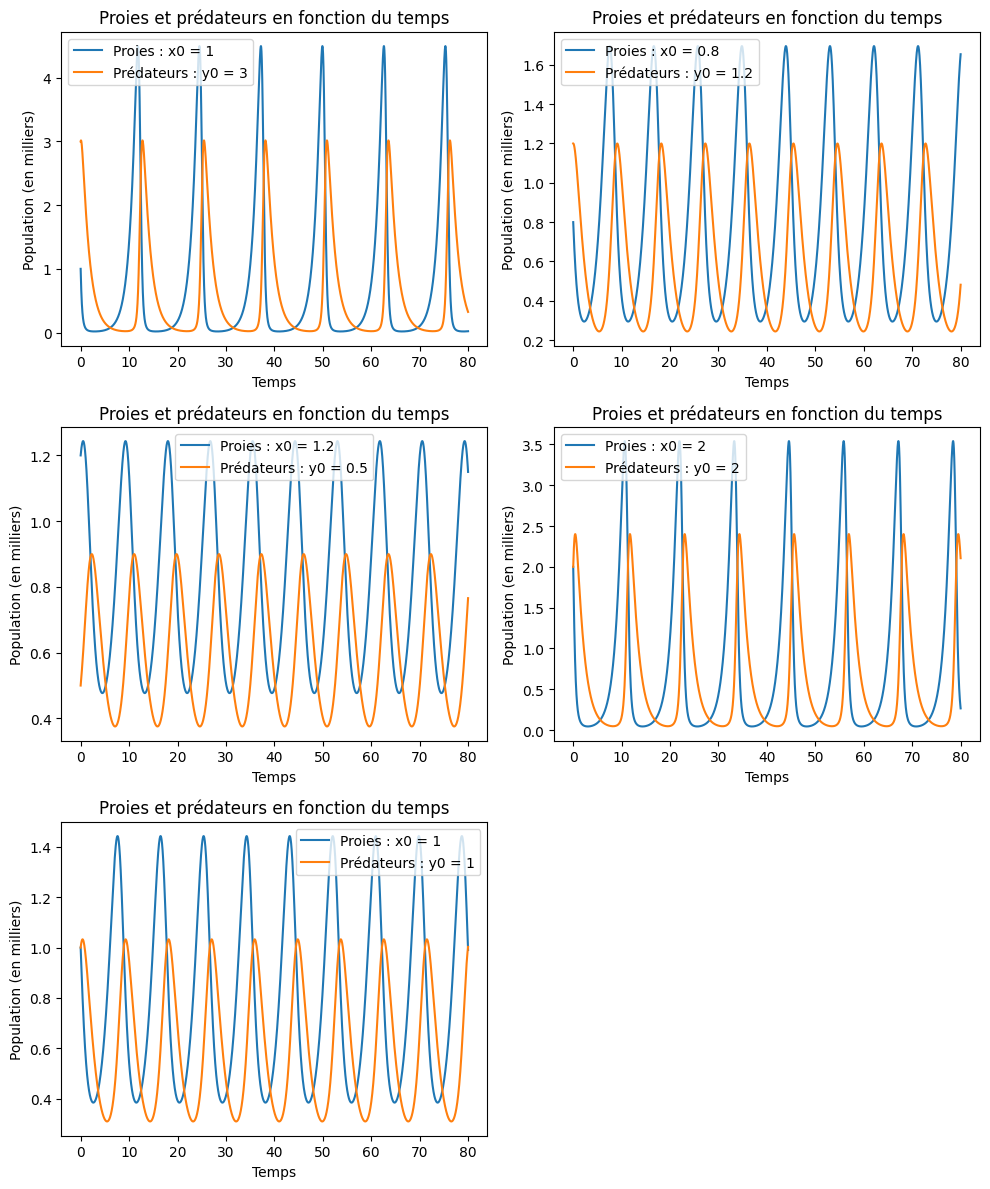

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12)) 

axes = axes.flatten()  

for i, (t, solutions) in enumerate(zip(t_list, v_list)):
    axes[i].plot(t, solutions[0], label=f'Proies : x0 = {v_ini_list[i][0]}')
    axes[i].plot(t, solutions[1], label=f'Prédateurs : y0 = {v_ini_list[i][1]}')
    axes[i].set_title('Proies et prédateurs en fonction du temps')
    axes[i].set_xlabel('Temps')
    axes[i].set_ylabel('Population (en milliers)')
    axes[i].legend()

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


On observe que les populations de proies et de prédateurs oscillent au cours du temps de manière périodique. On peut faire les mêmes observations que pour le diagramme de phase. On remarque que la population de proies augmente plus rapidement que la population de prédateurs et atteint des maxima plus élevés. On remarque également que la population de prédateurs atteint des minima plus bas que la population de proies. On peut donc dire que la population de prédateurs est plus sensible aux variations de la population de proies.

Ces analyses sont très intéressantes, mais elles ne représentent pas forcément la réalité. En effet, dans la nature, les populations de proies et de prédateurs ne varient pas de manière aussi régulière. Il y a de nombreux facteurs qui influencent les populations, comme la météo, la disponibilité de nourriture, les maladies, etc. Ces facteurs peuvent rendre les populations plus ou moins stables. Nous allons ici nous intéresser à un modèle plus réaliste, qui prend en compte la croissance logistique des proies. 

## __Croissance logistique des proies__

En réalité, la croissance des proies n'est pas illimitée car elle est limitée par les ressources disponibles. Pour rendre le modèle plus réaliste, on peut ajouter une croissance logistique des proies. Cela signifie que la croissance des proies est limitée par une capacité de charge, qui représente le nombre maximum de proies que l'environnement peut soutenir.
Les équations deviennent alors :

$$
\begin{cases}
x' = x(\alpha - \frac{\alpha x}{K} - \beta y) \\
y' = y(\mu x - \gamma)
\end{cases}
$$
où $K$ est la capacité de charge de l'environnement.

### __1.5. Résolution numérique des équations avec la croissance logistique des proies__
On va implémenter les nouvelles équations et les résoudre pour différentes conditions initiales et valeurs de $K$.  

Commençons par $K = 0.2$ (en termes de milliers d'individus).

In [16]:
# nouvelle fonction de Lotka-Volterra avec la logistique
alpha_logi = 4/5
beta_logi = 4/3
gamma_logi = 2/3
mu_logi = 5/6
K = 0.2

def lotka_volterra_logistique(t_i, v_i):
    """
        Système d'équations différentielles de Lotka-Volterra
        :param t_i: Temps à l'instant i
        :param v_i: Valeur de la fonction à l'instant i
        :return: Dérivée du système
    """
    global K
    x, y = v_i
    dx_dt = x * (alpha_logi - alpha_logi * x / K - beta_logi * y)
    dy_dt = y * (- gamma_logi + mu_logi * x)
    return np.array([dx_dt, dy_dt])

On résout de nouveau avec RK4 et on trace le diagramme de phase et l'évolution temporelle des populations.

In [17]:
v_ini_list = [(1, 3),(0.8, 1.2), (1.2, 0.5), (2, 2), (1, 1)]
step = 0.01
t_i = 0
t_f = 80
t_list_logi, v_list_logi= [], []
for v_ini in v_ini_list:
    t_logi, solutions_logi = integrate(t_i, t_f, step, v_ini, lotka_volterra_logistique)
    t_list_logi.append(t_logi)
    v_list_logi.append(solutions_logi)

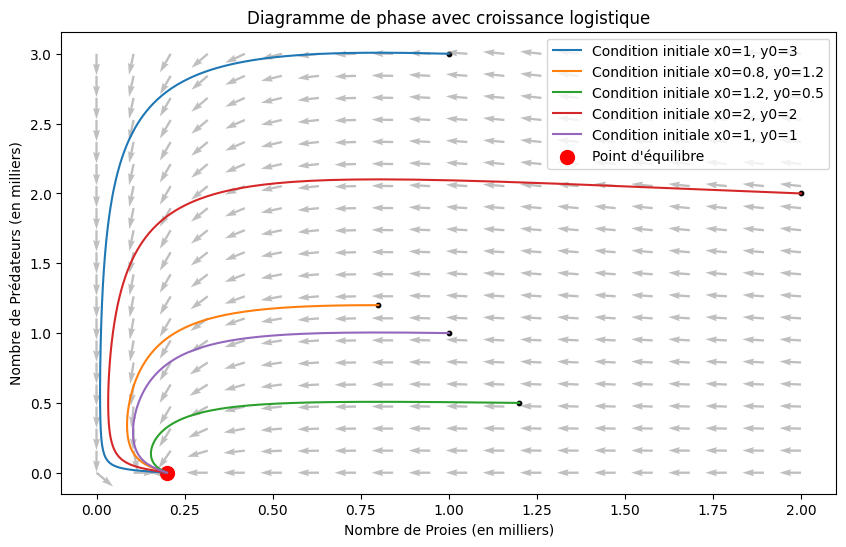

In [18]:
plt.figure(figsize=(10, 6))
for t_logi, solutions_logi, v_i in zip(t_list_logi, v_list_logi, v_ini_list):
    plt.plot(solutions_logi[0], solutions_logi[1], label=f'Condition initiale x0={v_i[0]}, y0={v_i[1]}')
    plt.scatter(v_i[0], v_i[1], c='black', s=10)

# Tracer les champs de vecteurs
x = np.linspace(1e-6, 2, 20)
y = np.linspace(1e-6, 3, 20)
X, Y = np.meshgrid(x, y)
U = X * (alpha - alpha*X / K - beta * Y)
V = Y * (-gamma + mu * X)
# Normalisation des vecteurs
norm = np.sqrt(U**2 + V**2)
U /= norm
V /= norm
plt.quiver(X, Y, U, V, color='gray', alpha=0.5)

plt.scatter(K, 0, c='red', s=100, label='Point d\'équilibre')
plt.xlabel('Nombre de Proies (en milliers)')
plt.ylabel('Nombre de Prédateurs (en milliers)')
plt.title('Diagramme de phase avec croissance logistique')
plt.legend()
plt.show()

Nous observons que pour $K = 0.2$, le nombre de proies diminue et le nombre de prédateurs augmente très légèrement puis à un moment donné, le nombre de prédateurs chute drastiquement jusqu'à 0. Cela est dû au fait que dans toutes les conditions initiales, le nombre de proies est supérieur à la capacité de charge. Les proies atteignent un équilibre stable et n'augmentent plus, ce qui est logique car elles sont limitées par la capacité de charge.

### __Analyse des points d'équilibre__
Expliquons théoriquement les points d'équilibre qui sont possibles pour n'importe quelle valeur de $K$.

Analytiquement, on a :
$$
\begin{cases}
x' = x(\alpha - \frac{\alpha x}{K} - \beta y) = 0 \\
y' = y(\mu x - \gamma) = 0
\end{cases}
$$
Pour la première équation, on a :
$$
x(\alpha - \frac{\alpha x}{K} - \beta y) = 0 \Rightarrow x = 0 \text{ ou } \alpha - \frac{\alpha x}{K} - \beta y = 0 \tag{1}$$ 
Pour la seconde équation, on a :
$$ y(\mu x - \gamma) = 0 \Rightarrow y = 0 \text{ ou } \mu x - \gamma = 0 \tag{2}$$

__Cas 1__ : $x = 0$  
Dans (2), on a soit $y = 0$ , soit $\mu \times 0 - \gamma = -\gamma \neq 0$ donc cela implique uniquement $y = 0$. Donc le point d'équilibre est $\boxed{(0,0)}$ qui n'est pas intéressant ici car cela signifie qu'il n'y a ni proies ni prédateurs.

__Cas 2__ : $y = 0$
Dans (1), on a soit $x = 0$ , soit $\alpha - \frac{\alpha x}{K} = 0$ donc cela implique $x = K$. Donc le point d'équilibre est $\boxed{(K,0)}$.

__Cas 3__ : $x \neq 0$ et $y \neq 0$  
On a de (2) : 
$$\mu x = \gamma \Rightarrow x = \frac{\gamma}{\mu}$$ 
 Puis en remplaçant dans (1) :
 
$$\alpha - \frac{\alpha \times \frac{\gamma}{\mu}}{K} - \beta y = 0 \Rightarrow y  = \frac{1}{\beta} \left( \alpha - \frac{\alpha\gamma}{K\mu} \right) = \frac{\alpha}{\beta} - \frac{\alpha\gamma}{K\mu\beta}$$

donc le point d'équilibre est $\boxed{\left(\frac{\gamma}{\mu}, \frac{\alpha}{\beta} - \frac{\alpha\gamma}{K\mu\beta}\right)}$.

Remarquons que si $\gamma \le K\mu$, alors $\frac {\alpha}{\beta} - \frac{\alpha\gamma}{K\mu\beta} \ge 0$ donc le point est biologiquement valide (valeurs positives).  
Si $\gamma \ge K\mu$, alors $\frac {\alpha}{\beta} - \frac{\alpha\gamma}{K\mu\beta} \le 0$ donc le point n'est pas biologiquement valide (valeurs négatives).

Appliquons cela à notre cas vu précédemment.  
Pour $K = 0.2$, on a  $\gamma = \frac{2}{3}$ et $K\mu = 0.2\times \frac{5}{6} = \frac{1}{6} $ donc $\gamma \ge K\mu$.  
Donc le seul point d'équilibre est
 $${(K,0)} = (0.2,0)$$
 Cela est conforme avec ce que l'on a observé précédemment.

De nouveau, représentons l'évolution temporelle des populations de proies et de prédateurs.

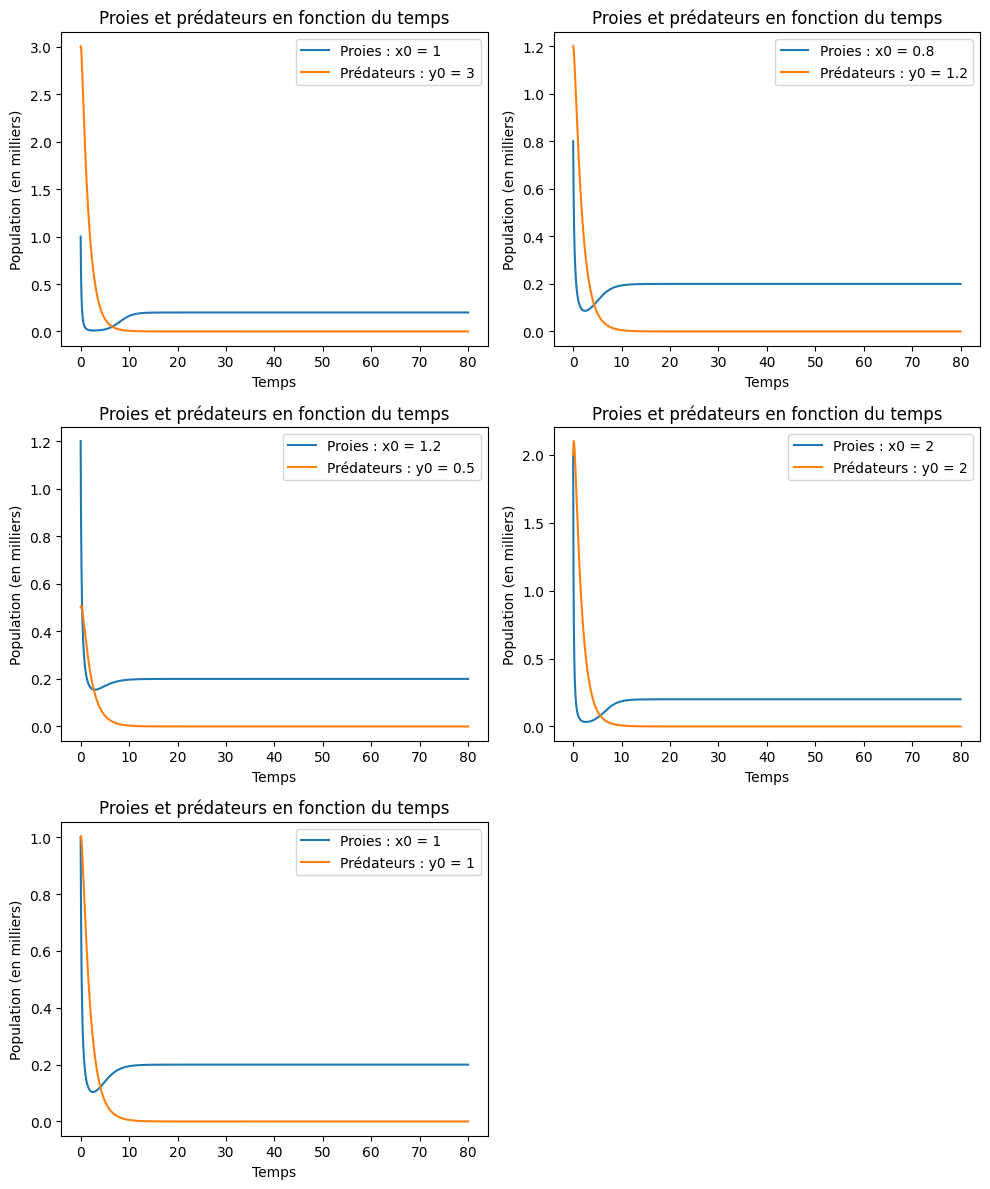

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))  
axes = axes.flatten()  

for i, (t_logi, solutions_logi) in enumerate(zip(t_list_logi, v_list_logi)):
    axes[i].plot(t_logi, solutions_logi[0], label=f'Proies : x0 = {v_ini_list[i][0]}')
    axes[i].plot(t_logi, solutions_logi[1], label=f'Prédateurs : y0 = {v_ini_list[i][1]}')
    axes[i].set_title('Proies et prédateurs en fonction du temps')
    axes[i].set_xlabel('Temps')
    axes[i].set_ylabel('Population (en milliers)')
    axes[i].legend()

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Contrairement aux équations classiques de Lotka-Volterra, la croissance logistique des proies prend en compte la capacité de charge de l'environnement.  
On remarque que les populations ne font plus des cycles, mais convergent vers un point d'équilibre stable.  
Pour cette valeur de $K$, on remarque que la population des prédateurs finit par s'éteindre. Cette situation est assez peu réaliste, car dans la nature, s'il reste des proies, les prédateurs peuvent survivre.  

Augmentons donc la valeur de $K$ à 3 (soit une capacité de charge de 3000 individus).

In [31]:
# Nouveau K
K = 3

# Résolution
v_ini_list = [(1, 3),(0.8, 1.2), (1.2, 0.5), (2, 2), (1, 1)]
step = 0.01
t_i = 0
t_f = 80
t_list_logi, v_list_logi= [], []
for v_ini in v_ini_list:
    t_logi, solutions_logi = integrate(t_i, t_f, step, v_ini, lotka_volterra_logistique)
    t_list_logi.append(t_logi)
    v_list_logi.append(solutions_logi)

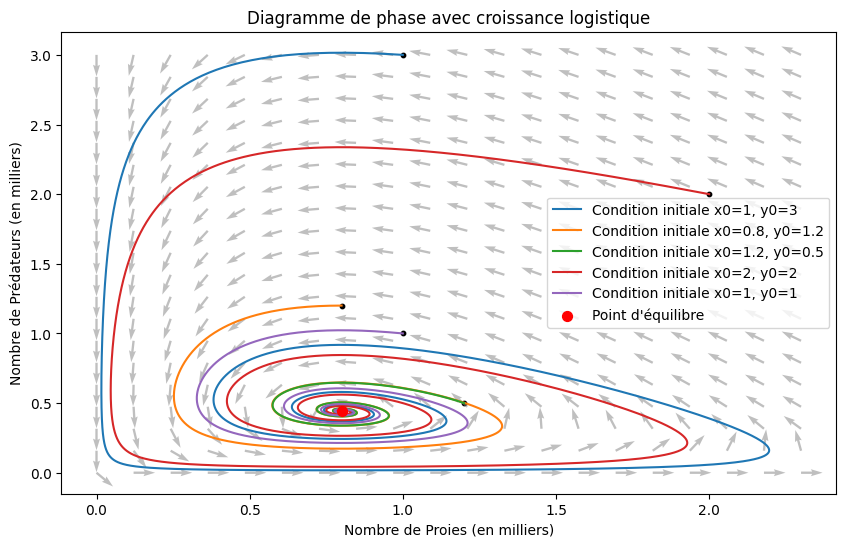

In [32]:
plt.figure(figsize=(10, 6))
for t_logi, solutions_logi, v_i in zip(t_list_logi, v_list_logi, v_ini_list):
    plt.plot(solutions_logi[0], solutions_logi[1], label=f'Condition initiale x0={v_i[0]}, y0={v_i[1]}')
    plt.scatter(v_i[0], v_i[1], c='black', s=10)

# Tracer les champs de vecteurs
x = np.linspace(1e-6, 2.3, 20)
y = np.linspace(1e-6, 3, 20)
X, Y = np.meshgrid(x, y)
U = X * (alpha - alpha*X / K - beta * Y)
V = Y * (-gamma + mu * X)
# Normalisation des vecteurs
norm = np.sqrt(U**2 + V**2)
U /= norm
V /= norm
plt.quiver(X, Y, U, V, color='gray', alpha=0.5)
plt.scatter(gamma/mu, alpha/beta - alpha*gamma/(K*mu*beta), c='red', s=50, label='Point d\'équilibre', zorder=5)
plt.xlabel('Nombre de Proies (en milliers)')
plt.ylabel('Nombre de Prédateurs (en milliers)')
plt.title('Diagramme de phase avec croissance logistique')
plt.legend()
plt.show()

Pour $K = 3$, on observe que les populations de proies et de prédateurs oscillent et finissent par atteindre un point d'équilibre stable. Cela signifie que les proies et les prédateurs coexistent de manière stable dans cet environnement.  
Lorsque la taille initiale de la population des proies est plus faible que celle de la population des prédateurs, on observe une convergence rapide vers le point d'équilibre.  
Lorsque la taille initiale de la population des proies est plus grande que celle de la population des prédateurs, on observe une convergence plus lente vers le point d'équilibre.  
Lorsque les deux tailles initiales sont égales, on observe que la convergence devient plus lente à mesure qu'elles augmentent.  

Analysons le point d'équilibre pour $K = 3$.
Cette fois-ci on a  $\gamma = \frac{2}{3}$ et $K\mu = 3\times \frac{5}{6} = \frac{5}{2} $ donc $\gamma \le K\mu$.  
Le point d'équilibre est donc :
 $$\left(\frac{\gamma}{\mu}, \frac{\alpha}{\beta} - \frac{\alpha\gamma}{K\mu\beta}\right) = (\frac{4}{5}, \frac{11}{25})$$  
Cela veut dire que les proies et les prédateurs coexistent de manière stable et que le nombre de proies est plus grand que celui des prédateurs. On observe bien la convergence vers le point d'équilibre qu'on obtient sur le graphe.  

Traçons de nouveau l'évolution temporelle des populations de proies et de prédateurs.

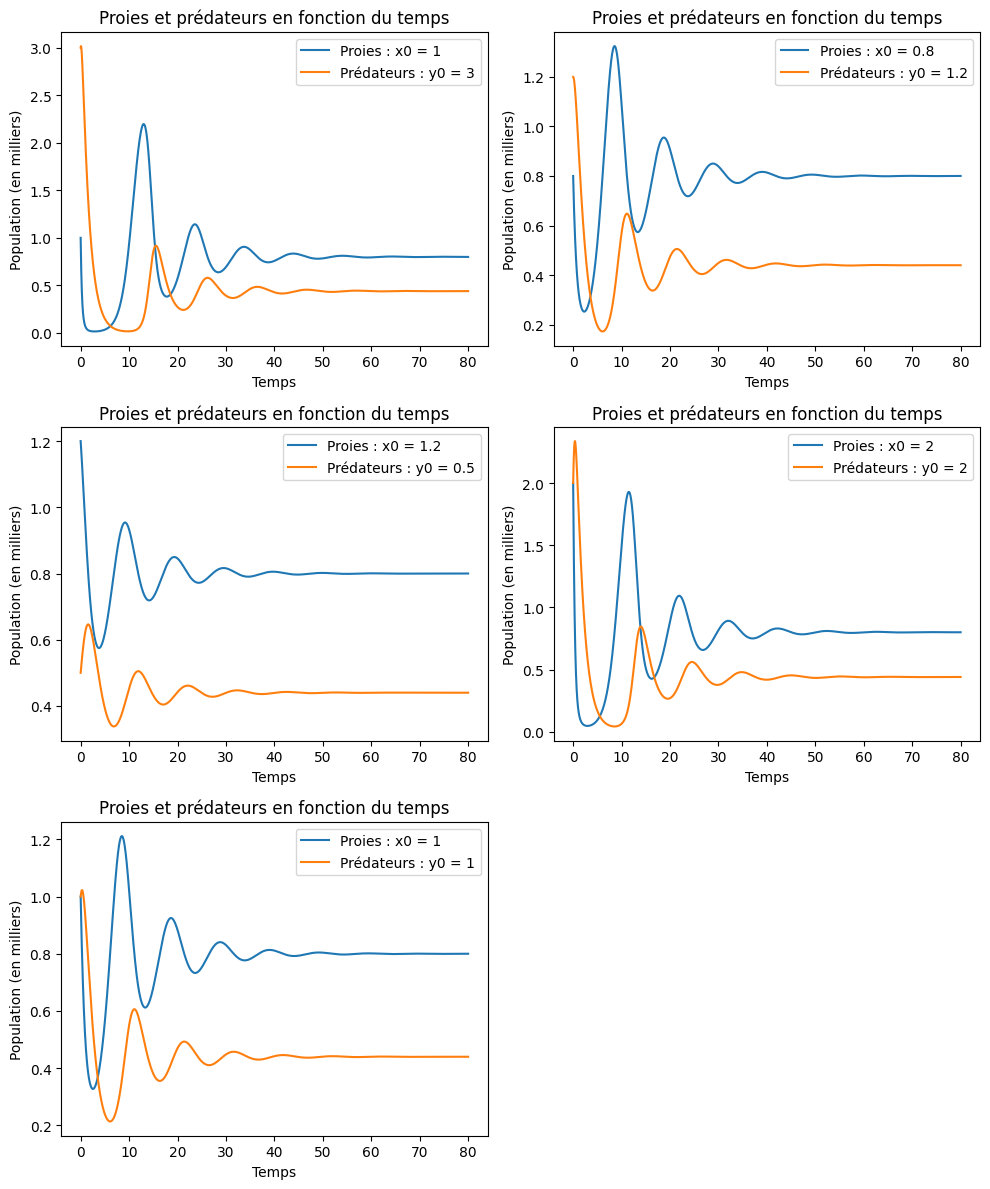

In [33]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))  

axes = axes.flatten()  

for i, (t_logi, solutions_logi) in enumerate(zip(t_list_logi, v_list_logi)):
    axes[i].plot(t_logi, solutions_logi[0], label=f'Proies : x0 = {v_ini_list[i][0]}')
    axes[i].plot(t_logi, solutions_logi[1], label=f'Prédateurs : y0 = {v_ini_list[i][1]}')
    axes[i].set_title('Proies et prédateurs en fonction du temps')
    axes[i].set_xlabel('Temps')
    axes[i].set_ylabel('Population (en milliers)')
    axes[i].legend()

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

On peut faire les mêmes commentaires que précédemment. On peut également remarquer que la population des proies est supérieure à celle des prédateurs jusqu'au point d'équilibre.

Cette situation est plus réaliste, car dans la nature, les populations de proies et de prédateurs restent tout de même assez stables sans que les prédateurs ne s'éteignent.

On peut donc en conclure que les cas où la capacité de charge est faible sont peu réalistes, tandis que les cas où la capacité de charge est élevée sont plus réalistes. Cela est normal car la capacité de charge dans la nature est souvent élevée.

Pour autant, est-ce qu'atteindre un point où plus rien n'évolue est réaliste ? La nature est-elle vraiment statique ?

### __Discussion de la partie 1__
Nous avons étudié les équations de Lotka-Volterra et leur résolution numérique. Nous avons observé que les populations de proies et de prédateurs oscillent autour d'un point d'équilibre stable, qui correspond à une coexistence des deux populations. Nous avons également ajouté une croissance logistique des proies pour rendre le modèle plus réaliste. Nous avons observé que la croissance logistique des proies permet de stabiliser les populations de proies et de prédateurs, et que la capacité de charge influence la dynamique des populations.

Nous nous rendons compte que le modèle de Lotka-Volterra est un modèle simplifié qui ne prend pas en compte de nombreux facteurs qui influencent les populations dans la nature. En effet, les comportements individuels des proies et des prédateurs, les interactions entre les individus, la compétition entre les espèces, la disponibilité de nourriture... ne sont pas pris en compte dans ce modèle.  
De plus, on remarque que si on relance le modèle avec les mêmes conditions initiales, on obtient les mêmes résultats. Le modèle est donc déterministe et ne prend pas en compte le hasard, ni les fluctuations statistiques des populations, ce qui n'est pas très réaliste.

Nous allons donc modéliser le comportement individuel des proies et des prédateurs en utilisant des automates cellulaires, ce qui sera bien plus représentatif de la réalité.